In [3]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import os

In [4]:
dataset = pd.read_csv('/content/drive/MyDrive/data/EngineFaultDB_Final.csv')
dataset.head()

,Fault,MAP,TPS,Force,Power,RPM,Consumption L/H,Consumption L/100KM,Speed,CO,HC,CO2,O2,Lambda,AFR
0,0,3.549,1.889,7.428,5.227,1192.769,3.057,11.720,24.901,0.460,196.089,14.356,1.080,1.047,15.385
1,0,3.559,1.899,7.646,5.327,1145.191,2.914,11.276,25.030,0.478,196.283,14.492,1.107,1.083,15.926
2,0,3.539,1.899,7.578,5.100,1208.505,2.976,11.926,24.213,0.464,200.367,14.443,1.099,1.072,15.754
3,0,3.519,1.889,7.371,5.255,1164.127,2.908,11.786,24.407,0.471,195.345,13.853,1.076,1.006,14.787
4,0,3.549,1.879,7.405,5.177,1172.032,2.898,12.169,24.875,0.468,194.979,13.752,1.060,0.984,14.470


In [6]:
dataset['Fault'].unique()

array([0, 1, 2, 3])

In [7]:
count = dataset['Fault'].value_counts()
count

,count
Fault,
0,16000
2,15000
3,14001
1,10998


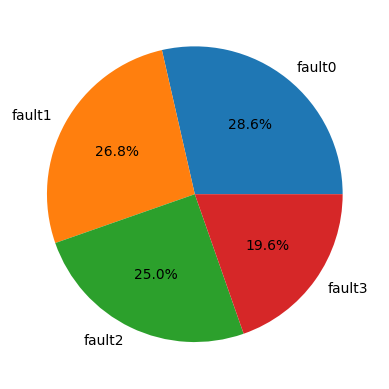

In [17]:
plt.pie(x = count, labels = [f'fault{i}' for i in dataset['Fault'].unique().astype(str)], autopct = '%1.1f%%')
plt.show()

So first we are going to train the model on healthy data set and teach the model what healthy data looks like so when we do give it faulty data it will flag it wrong

aand for that we need a df of only healthy data letss create that

In [18]:
healthy_dataset = dataset[dataset['Fault'] == 0]
healthy_dataset.shape

(16000, 15)

In [20]:
healthy_dataset = healthy_dataset.drop('Fault', axis=1)

In [22]:
# This is the what is going to be fed into the nn it is basically converting the original dataswetinto a numpy array
healthy_input = healthy_dataset.values

In [23]:
from sklearn.model_selection import train_test_split

In [27]:
healthy_train, healthy_test = train_test_split(
    healthy_input, test_size=0.2, random_state=42)
print(f'Good train cound: {len(healthy_train)}' )
print(f'Good test cound: {len(healthy_test)}' )

Good train cound: 12800
Good test cound: 3200


In [30]:
from matplotlib.colors import Normalize
from sklearn.preprocessing import Normalizer, MinMaxScaler
from sklearn.pipeline import Pipeline

#configure out pipeline

pipeline = Pipeline([('normalize', Normalizer()),
                     ('Scalar', MinMaxScaler())])

pipeline.fit(healthy_train)

Pipeline(steps=[('normalize', Normalizer()), ('Scalar', MinMaxScaler())])

In [32]:
#transform the training and validaton data with these parameters

train_transformed = pipeline.transform(healthy_train)
test_transformed = pipeline.transform(healthy_test)

Model Engineering

In [33]:
input_dimensions = train_transformed.shape[1]

In [35]:
from sklearn import metrics
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense


model = Sequential()

model.add(Dense(10, input_dim = input_dimensions, activation = 'relu')) #inpu dimensions equal to number of features/columnns
model.add(Dense(3, activation = 'relu'))
model.add(Dense(10, activation = 'relu'))
model.add(Dense(input_dimensions))




/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


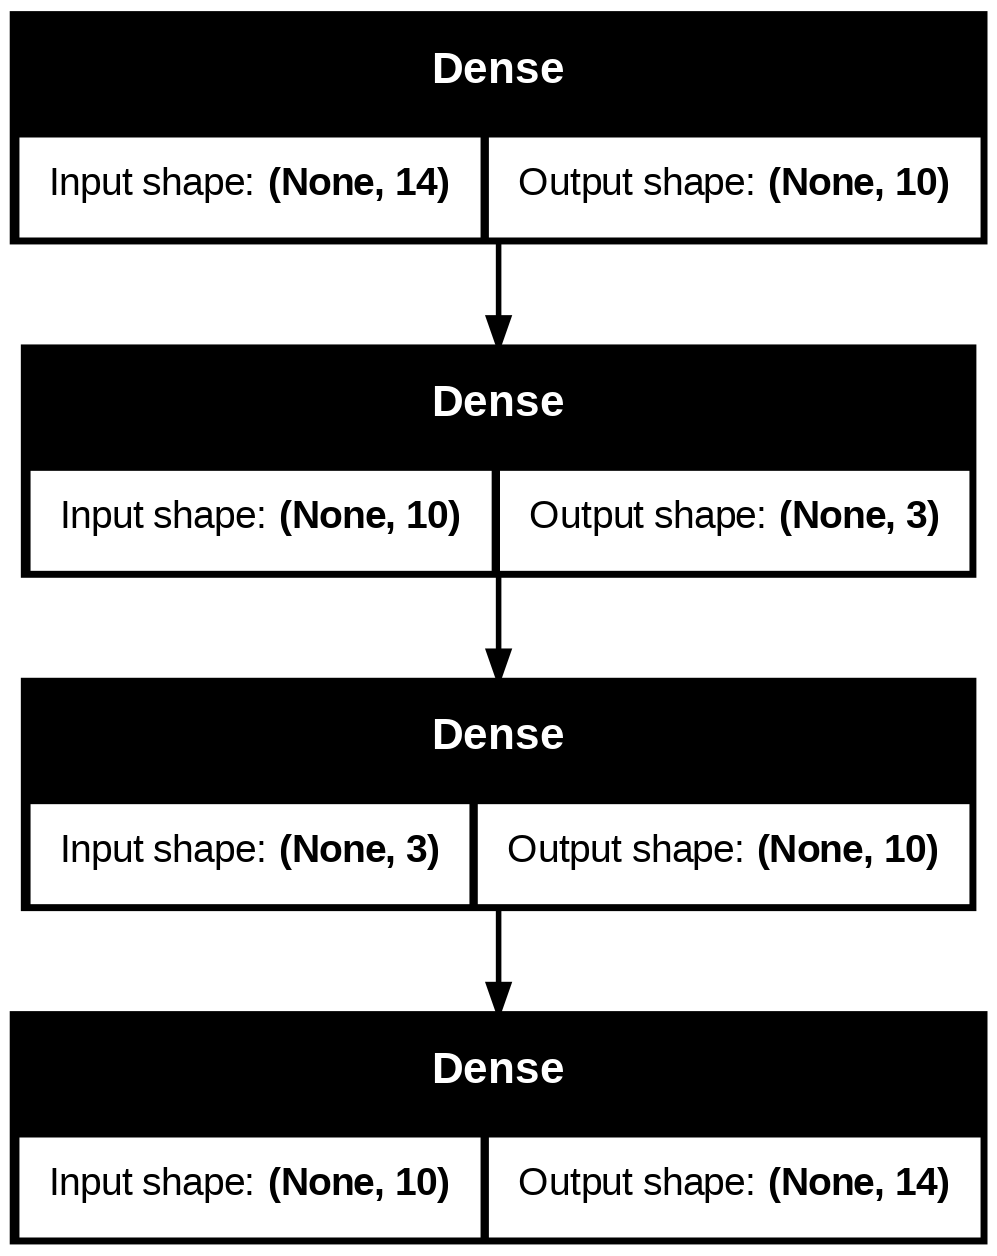

In [36]:
tf.keras.utils.plot_model(model, show_shapes=True)

In [46]:
model.compile(loss='mean_squared_error', optimizer = 'adam')



In [47]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 10)             │           150 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │            33 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │            40 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 14)             │           154 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 377 (1.47 KB)

 Trainable params: 377 (1.47 KB)

 Non-trainable params: 0 (0.00 B)

In [48]:
BATCH_SIZE =1026
EPOCHS = 200
history = model.fit(train_transformed, train_transformed,
                    verbose = 1 ,
                    epochs = EPOCHS,
                    batch_size = BATCH_SIZE,
                    validation_data = (train_transformed, train_transformed))

Epoch 1/200
13/13 ━━━━━━━━━━━━━━━━━━━━ 4s 114ms/step - loss: 0.2681 - val_loss: 0.2562
Epoch 2/200
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.2489 - val_loss: 0.2403
Epoch 3/200
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.2339 - val_loss: 0.2257
Epoch 4/200
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.2188 - val_loss: 0.2099
Epoch 5/200
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.2025 - val_loss: 0.1927
Epoch 6/200
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.1843 - val_loss: 0.1736
Epoch 7/200
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.1652 - val_loss: 0.1546
Epoch 8/200
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.1464 - val_loss: 0.1363
Epoch 9/200
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.1291 - val_loss: 0.1206
Epoch 10/200
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.1145 - val_loss: 0.1072
Epoch 11/200
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.1019 - val_loss: 0.0955
Epoch 12/200
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss:

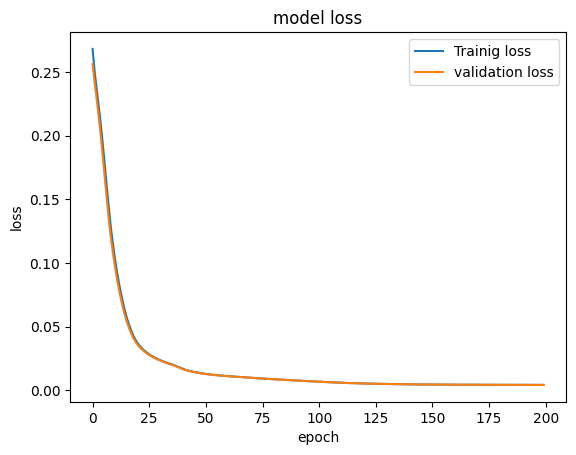

In [49]:
plt.plot(history.history['loss'], label = 'Trainig loss')
plt.plot(history.history['val_loss'], label = 'validation loss')
plt.title('model loss')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend()

now our model knowas what good data looks like lets feed it data with anomalies

In [50]:
fault1_dataset = dataset[dataset['Fault'] == 1]
fault1_dataset.shape

fault1_dataset = fault1_dataset.drop('Fault', axis=1)

fault1_input = fault1_dataset.values
faulty_transformeddata = pipeline.transform(fault1_input)

In [51]:
reconstruction_faulty  = model.predict(faulty_transformeddata)

reconstructions_error_normal_train = np.mean(np.abs(faulty_transformeddata  - reconstruction_faulty), axis = 1)

344/344 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


In [52]:
reconstruction_faulty  = model.predict(faulty_transformeddata)

reconstructions_error_normal_train = np.mean(np.abs(train_transformed  - reconstruction_faulty), axis = 1)

344/344 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step


ValueError: operands could not be broadcast together with shapes (12800,14) (10998,14) 